#  Limpieza de Clase 0 - Eliminación de Casos Ambiguos

**Objetivo:** Identificar y eliminar ejemplos de la clase 0 (No ofensivo) que probablemente están mal etiquetados.

**Estrategia:**
1. Detectar textos con palabras ofensivas en clase 0
2. Analizar contexto para identificar mal etiquetado
3. Eliminar casos claramente problemáticos
4. Preparar dataset limpio para balanceo

**Dataset original:** 6,000 ejemplos (4,433 clase 0, 1,567 clase 1)

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path
from collections import Counter

# Configuración
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [2]:

# Cargar
df = pd.read_csv('../data/raw/zenodo_procesado.csv')

print(f"{'='*70}")
print(f"DATASET ORIGINAL")
print(f"{'='*70}")

print(f"\n Total: {len(df):,} ejemplos")

distribucion = df['label'].value_counts().sort_index()
for label, count in distribucion.items():
    pct = (count / len(df)) * 100
    nombre = "No ofensivo" if label == 0 else "Ofensivo"
    print(f"   Clase {label} ({nombre}): {count:,} ({pct:.1f}%)")

ratio = max(distribucion) / min(distribucion)
print(f"\n Ratio: {ratio:.2f}:1")

DATASET ORIGINAL

 Total: 6,000 ejemplos
   Clase 0 (No ofensivo): 4,433 (73.9%)
   Clase 1 (Ofensivo): 1,567 (26.1%)

 Ratio: 2.83:1


## 1. Identificar Casos Problemáticos en Clase 0

Vamos a buscar textos etiquetados como "No ofensivo" (clase 0) pero que contienen palabras claramente ofensivas.

In [3]:

print(f"{'='*70}")
print(f"ANÁLISIS DE CASOS SOSPECHOSOS EN CLASE 0")
print(f"{'='*70}")

# Palabras claramente ofensivas (insultos directos)
palabras_ofensivas_fuertes = [
    'gilipollas', 'subnormal', 'imbécil', 'idiota', 'retrasado',
    'maricón', 'puta', 'puto', 'mierda', 'mongolo', 'monguer',
    'cabrón', 'hijoputa', 'hijo de puta', 'tonto del culo',
    'payaso', 'estúpido', 'inútil', 'basura', 'escoria'
]

# Crear patrón regex
patron_ofensivo = '|'.join([rf'\b{re.escape(p)}\b' for p in palabras_ofensivas_fuertes])

# Filtrar clase 0 con palabras ofensivas
df_clase_0 = df[df['label'] == 0].copy()

df_clase_0['tiene_ofensivas'] = df_clase_0['texto'].str.contains(
    patron_ofensivo,
    case=False,
    regex=True,
    na=False
)

casos_sospechosos = df_clase_0[df_clase_0['tiene_ofensivas']].copy()

print(f"\n Análisis de clase 0:")
print(f"   Total clase 0: {len(df_clase_0):,}")
print(f"   Con palabras ofensivas: {len(casos_sospechosos):,} ({len(casos_sospechosos)/len(df_clase_0)*100:.1f}%)")
print(f"   Sin palabras ofensivas: {len(df_clase_0) - len(casos_sospechosos):,}")

# Mostrar ejemplos
print(f"\n EJEMPLOS DE CASOS SOSPECHOSOS (primeros 20):")
print(f"{'-'*70}")

for i, (idx, row) in enumerate(casos_sospechosos.head(20).iterrows(), 1):
    texto = row['texto']
    texto_mostrar = texto if len(texto) <= 100 else texto[:97] + '...'
    print(f"{i:2d}. {texto_mostrar}")

ANÁLISIS DE CASOS SOSPECHOSOS EN CLASE 0

 Análisis de clase 0:
   Total clase 0: 4,433
   Con palabras ofensivas: 741 (16.7%)
   Sin palabras ofensivas: 3,692

 EJEMPLOS DE CASOS SOSPECHOSOS (primeros 20):
----------------------------------------------------------------------
 1. La gente que se pretende burlar del feminismo diciendo "machista opresor" es porque no ha cogido ...
 2. En qué puto momento tumblr decidió que "ojos negros como pozos" y "piel aceitunada" era ser BLANC...
 3. @MrAlvatros25 @Edd33Martin ha hecho las dos subnormal
 4. @Francis76440634 El día que Preescolar ataque a la Izquierda, ese día me haré maricón, o sea NUNC...
 5. Me siento profundamente subnormal empatizando tanto con mis propios personajes.
 6. @FeelSpheal Me hice pasar por tia una vez en el lol y me llamaron feminazi, puta guarra, zorra y ...
 7. Paz Vega va peinada como uno que estaba en mi clase del colegio que era monguer. #goya2017
 8. Tio me estoy descojonandones que es subnormal ahora me entra 

## 2. Análisis de Patrones

Vamos a analizar si estos casos sospechosos tienen patrones que indiquen mal etiquetado.

In [4]:
print(f"{'='*70}")
print(f"ANÁLISIS DE PATRONES")
print(f"{'='*70}")

# Detectar diferentes tipos de casos problemáticos

# PATRÓN 1: Insultos directos (eres X, tonto X)
patron_insulto_directo = r'\b(eres|sois|sos|ere)\s+(un\s+)?(gilipollas|subnormal|imbécil|idiota|retrasado|maricón|puto|puta|mongolo|tonto|estúpido|inútil)\b'

casos_sospechosos['insulto_directo'] = casos_sospechosos['texto'].str.contains(
    patron_insulto_directo,
    case=False,
    regex=True,
    na=False
)

insultos_directos = casos_sospechosos[casos_sospechosos['insulto_directo']]

print(f"\n📌 PATRÓN 1: Insultos directos (eres X, sois X)")
print(f"   Encontrados: {len(insultos_directos):,} casos")
print(f"\n   Ejemplos:")
for i, texto in enumerate(insultos_directos['texto'].head(10), 1):
    texto_mostrar = texto if len(texto) <= 100 else texto[:97] + '...'
    print(f"   {i:2d}. {texto_mostrar}")

# PATRÓN 2: Contexto político (puede ser legítimo)
patron_politico = r'\b(facha|fascista|independentista|catalán|rajoy|podemos|pp|psoe|vox|dictador)\b'

casos_sospechosos['contexto_politico'] = casos_sospechosos['texto'].str.contains(
    patron_politico,
    case=False,
    regex=True,
    na=False
)

contexto_politico = casos_sospechosos[casos_sospechosos['contexto_politico']]

print(f"\n📌 PATRÓN 2: Contexto político")
print(f"   Encontrados: {len(contexto_politico):,} casos")
print(f"   (Estos pueden ser legítimos - crítica política, no bullying)")

# PATRÓN 3: Auto-referencia (yo soy X, parezco X)
patron_auto = r'\b(soy|parezco|me\s+siento|estoy)\s+(un\s+)?(subnormal|tonto|idiota|mongolo)\b'

casos_sospechosos['auto_referencia'] = casos_sospechosos['texto'].str.contains(
    patron_auto,
    case=False,
    regex=True,
    na=False
)

auto_referencia = casos_sospechosos[casos_sospechosos['auto_referencia']]

print(f"\n📌 PATRÓN 3: Auto-referencia (yo soy X)")
print(f"   Encontrados: {len(auto_referencia):,} casos")
print(f"   (Estos probablemente SÍ son clase 0 - autoinsulto/humor)")

# PATRÓN 4: Insulto SIN contexto político (probablemente mal etiquetado)
casos_problematicos = casos_sospechosos[
    casos_sospechosos['insulto_directo'] & 
    ~casos_sospechosos['contexto_politico'] &
    ~casos_sospechosos['auto_referencia']
]

print(f"\n📌 CASOS CLARAMENTE PROBLEMÁTICOS:")
print(f"   Insultos directos SIN contexto político ni auto-referencia")
print(f"   Total: {len(casos_problematicos):,} casos")
print(f"\n   Ejemplos (primeros 15):")
for i, texto in enumerate(casos_problematicos['texto'].head(15), 1):
    texto_mostrar = texto if len(texto) <= 100 else texto[:97] + '...'
    print(f"   {i:2d}. {texto_mostrar}")

ANÁLISIS DE PATRONES

📌 PATRÓN 1: Insultos directos (eres X, sois X)
   Encontrados: 17 casos

   Ejemplos:
    1. buena hora para recordar que gummy eres subnormal
    2. @Drix97 @DexertoPaco Joel, eres retrasado.  Sin embargo, mis dieses por la foto xD
    3. No aguanto un minuto calentando la leche en el micro, te voy a aguantar a ti que eres subnormal, ...
    4. Pero tú eres subnormal o que te pasa? https://t.co/M41bqS4xIp
    5. @pmanglano @19maurice69 Low Countries, jajajajajaja. Percival, eres subnormal.
    6. @jory_wolf @RockMarcos11 @jmdiaz1945 @policia Eres subnormal. No hahaha, es humor negro.
    7. El humor negro no es humor es sólo una muestra más de que sois gilipollas
    8. Para un machunazi eres maricón si sales en defensa de los homosexuales. Si das la cara por una mu...
    9. @lucascabj1905 Pero chaval, tu eres subnormal?
   10. Te inventas que el feminismo te oprime mientras curras 12h al día por un salario de miseria y ahí...

📌 PATRÓN 2: Contexto político
   E

C:\Users\gemit\AppData\Local\Temp\ipykernel_29228\548396938.py:10: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  casos_sospechosos['insulto_directo'] = casos_sospechosos['texto'].str.contains(
C:\Users\gemit\AppData\Local\Temp\ipykernel_29228\548396938.py:29: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  casos_sospechosos['contexto_politico'] = casos_sospechosos['texto'].str.contains(
C:\Users\gemit\AppData\Local\Temp\ipykernel_29228\548396938.py:45: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  casos_sospechosos['auto_referencia'] = casos_sospechosos['texto'].str.contains(


## 3. Decisión: ¿Qué Eliminar?

Vamos a ser **conservadores** y solo eliminar casos **muy claramente** mal etiquetados.

In [6]:
print(f"{'='*70}")
print(f"SELECCIÓN DE CASOS A ELIMINAR - CRITERIOS AMPLIADOS")
print(f"{'='*70}")

# ============================================================
# NIVEL 1: Insultos directos (YA LOS TENEMOS)
# ============================================================

nivel_1 = casos_problematicos.copy()

print(f"\n NIVEL 1 - Alta confianza (insultos directos):")
print(f"   Casos: {len(nivel_1):,}")

# ============================================================
# NIVEL 2: Textos con MÚLTIPLES palabras ofensivas
# ============================================================

# Contar cuántas palabras ofensivas tiene cada texto
def contar_ofensivas(texto):
    """Cuenta cuántas palabras ofensivas diferentes contiene un texto"""
    texto_lower = texto.lower()
    count = 0
    for palabra in palabras_ofensivas_fuertes:
        if re.search(rf'\b{re.escape(palabra)}\b', texto_lower):
            count += 1
    return count

casos_sospechosos['num_ofensivas'] = casos_sospechosos['texto'].apply(contar_ofensivas)

# Textos con 2 o más palabras ofensivas diferentes (muy sospechoso)
multiples_ofensivas = casos_sospechosos[
    (casos_sospechosos['num_ofensivas'] >= 2) &
    ~casos_sospechosos['auto_referencia']  # Excepto auto-referencias
].copy()

print(f"\n NIVEL 2 - Confianza media (múltiples palabras ofensivas):")
print(f"   Casos con 2+ palabras ofensivas: {len(multiples_ofensivas):,}")
print(f"\n   Ejemplos (primeros 10):")
for i, (idx, row) in enumerate(multiples_ofensivas.head(10).iterrows(), 1):
    texto = row['texto']
    texto_mostrar = texto if len(texto) <= 100 else texto[:97] + '...'
    print(f"   {i:2d}. [{row['num_ofensivas']} palabras] {texto_mostrar}")

# ============================================================
# NIVEL 3: Patrones específicos de degradación
# ============================================================

# Patrones de degradación directa
patrones_degradacion = [
    r'\b(vete|iros|largaos|piérdete)\s+(a|al)\s+(la\s+)?(mierda|carajo|infierno|tomar por (el )?culo)\b',
    r'\b(callate|cállate|cierra)\s+(la\s+)?(puta\s+)?boca\b',
    r'\bque\s+(te|os)\s+(jodan|den|follen)\b',
    r'\bme\s+cagas?\s+(a|en)\b',
    r'\beres\s+una?\s+(puta\s+)?basura\b',
    r'\bno\s+vales?\s+(para\s+)?nada\b',
]

patron_degradacion = '|'.join(patrones_degradacion)

casos_sospechosos['tiene_degradacion'] = casos_sospechosos['texto'].str.contains(
    patron_degradacion,
    case=False,
    regex=True,
    na=False
)

degradacion = casos_sospechosos[
    casos_sospechosos['tiene_degradacion'] &
    ~casos_sospechosos['contexto_politico']  # Excepto contexto político
]

print(f"\n NIVEL 3 - Patrones de degradación:")
print(f"   Casos: {len(degradacion):,}")
print(f"\n   Ejemplos (primeros 8):")
for i, texto in enumerate(degradacion['texto'].head(8), 1):
    texto_mostrar = texto if len(texto) <= 100 else texto[:97] + '...'
    print(f"   {i:2d}. {texto_mostrar}")

# ============================================================
# COMBINAR TODOS LOS NIVELES (sin duplicados)
# ============================================================

# Unir todos los índices
indices_nivel_1 = set(nivel_1.index)
indices_nivel_2 = set(multiples_ofensivas.index)
indices_nivel_3 = set(degradacion.index)

# Combinar
indices_eliminar_total = indices_nivel_1 | indices_nivel_2 | indices_nivel_3

print(f"\n{'='*70}")
print(f"RESUMEN DE ELIMINACIÓN")
print(f"{'='*70}")

print(f"\n Desglose por nivel:")
print(f"   Nivel 1 (insultos directos):        {len(indices_nivel_1):4,} casos")
print(f"   Nivel 2 (múltiples ofensivas):      {len(indices_nivel_2):4,} casos")
print(f"   Nivel 3 (patrones degradación):     {len(indices_nivel_3):4,} casos")
print(f"   {'-'*50}")
print(f"   TOTAL (sin duplicados):             {len(indices_eliminar_total):4,} casos")

# Solapamientos
solo_nivel_1 = len(indices_nivel_1 - indices_nivel_2 - indices_nivel_3)
solo_nivel_2 = len(indices_nivel_2 - indices_nivel_1 - indices_nivel_3)
solo_nivel_3 = len(indices_nivel_3 - indices_nivel_1 - indices_nivel_2)
multiple = len(indices_eliminar_total) - solo_nivel_1 - solo_nivel_2 - solo_nivel_3

print(f"\n Solapamientos:")
print(f"   Solo Nivel 1: {solo_nivel_1:,}")
print(f"   Solo Nivel 2: {solo_nivel_2:,}")
print(f"   Solo Nivel 3: {solo_nivel_3:,}")
print(f"   Múltiples criterios: {multiple:,}")

# ============================================================
# CALCULAR IMPACTO
# ============================================================

clase_0_antes = len(df[df['label'] == 0])
clase_0_despues = clase_0_antes - len(indices_eliminar_total)
clase_1 = len(df[df['label'] == 1])

print(f"\n{'='*70}")
print(f"IMPACTO EN EL DATASET")
print(f"{'='*70}")

print(f"\n Clase 0:")
print(f"   Antes:     {clase_0_antes:,} ejemplos")
print(f"   Eliminar:  {len(indices_eliminar_total):,} ejemplos ({len(indices_eliminar_total)/clase_0_antes*100:.1f}%)")
print(f"   Después:   {clase_0_despues:,} ejemplos")

print(f"\n Clase 1:")
print(f"   Sin cambios: {clase_1:,} ejemplos")

nuevo_ratio = clase_0_despues / clase_1

print(f"\n Balance:")
print(f"   Ratio ANTES:   {max(df['label'].value_counts())/min(df['label'].value_counts()):.2f}:1")
print(f"   Ratio DESPUÉS: {nuevo_ratio:.2f}:1")

mejora = ((max(df['label'].value_counts())/min(df['label'].value_counts())) - nuevo_ratio)
print(f"   Mejora:        {mejora:.2f} puntos")

if nuevo_ratio < 2.5:
    print(f"    Mejora significativa")
elif nuevo_ratio < 2.7:
    print(f"    Mejora moderada")
else:
    print(f"    Mejora leve")

# ============================================================
# ESTIMAR SINTÉTICOS NECESARIOS
# ============================================================

sinteticos_necesarios = clase_0_despues - clase_1

print(f"\n{'='*70}")
print(f"PRÓXIMO PASO: GENERAR SINTÉTICOS")
print(f"{'='*70}")

print(f"\n Para balancear perfectamente (50/50):")
print(f"   Clase 0 limpia:           {clase_0_despues:,} ejemplos")
print(f"   Clase 1 actual:           {clase_1:,} ejemplos")
print(f"   Sintéticos a generar:     {sinteticos_necesarios:,} ejemplos")

print(f"\n Dataset final objetivo:")
print(f"   Clase 0: {clase_0_despues:,} (reales limpios)")
print(f"   Clase 1: {clase_0_despues:,} ({clase_1:,} reales + {sinteticos_necesarios:,} sintéticos)")
print(f"   TOTAL:   {clase_0_despues * 2:,} ejemplos")
print(f"   Ratio:   1.00:1 ")

# Guardar la lista de índices para la siguiente celda
indices_eliminar = list(indices_eliminar_total)

print(f"\n Análisis completado")

SELECCIÓN DE CASOS A ELIMINAR - CRITERIOS AMPLIADOS

 NIVEL 1 - Alta confianza (insultos directos):
   Casos: 17

 NIVEL 2 - Confianza media (múltiples palabras ofensivas):
   Casos con 2+ palabras ofensivas: 47

   Ejemplos (primeros 10):
    1. [2 palabras] YouTube/Internet -Da todo el puto asco -Nos hemos vuelto locxs? -Hipocresía everywhere xd -Mucho ...
    2. [2 palabras] @FerraxPLS @SoyMasacre Juro que tengo más de 14 años y no soy un puto retrasado sin cabeza
    3. [2 palabras] pero el concepto, ¿no? te viene un homófobo por la calle y te dice "maricón de mierda" y le dices...
    4. [2 palabras] ¿Por qué no seguía a la cuenta de @EnglandRugby? ¿Acaso soy un puto subnormal?
    5. [2 palabras] @kajalnapalm no veo nada por culpa del sol y  llevo la gorra hacia atras puto subnormal
    6. [2 palabras] Puto Subnormal Weaboo https://t.co/v2qUQagNwV
    7. [2 palabras] Pues no me viene uno anoche y me dice que es el puto amo, que es guapo y que le elija a él. Cómo ...
    8. [2 pal

C:\Users\gemit\AppData\Local\Temp\ipykernel_29228\2296182928.py:60: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  casos_sospechosos['tiene_degradacion'] = casos_sospechosos['texto'].str.contains(


## 4. Aplicar Limpieza y Guardar

Eliminamos los casos problemáticos y guardamos el dataset limpio.

APLICANDO LIMPIEZA AL DATASET

 Limpieza aplicada

 Dataset limpio:
   Total: 5,935 ejemplos
   Clase 0 (No ofensivo): 4,368 (73.6%)
   Clase 1 (Ofensivo): 1,567 (26.4%)

 Nuevo ratio: 2.79:1


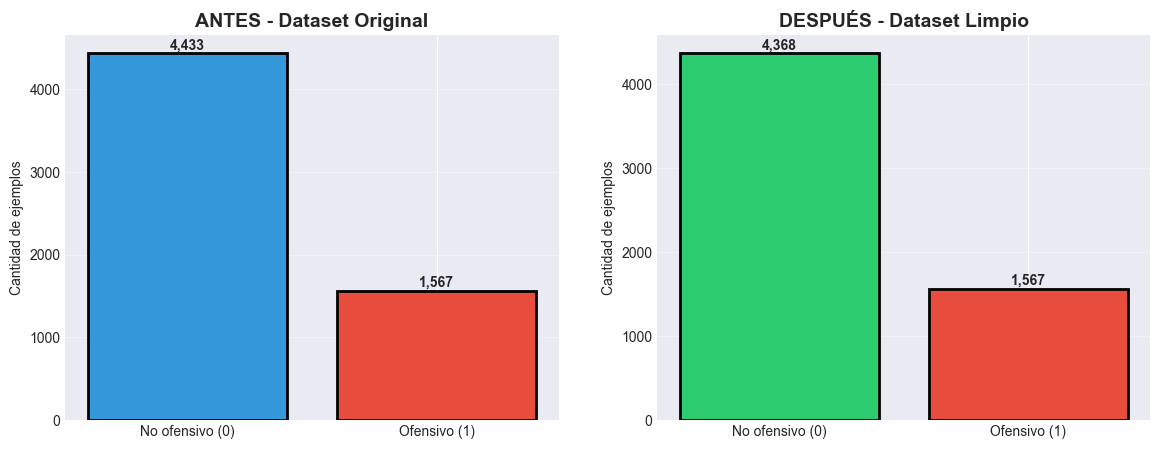

In [7]:

print(f"{'='*70}")
print(f"APLICANDO LIMPIEZA AL DATASET")
print(f"{'='*70}")

# Crear dataset limpio
df_limpio = df.drop(index=indices_eliminar).copy()

# Resetear índices
df_limpio = df_limpio.reset_index(drop=True)

# Verificar
print(f"\n Limpieza aplicada")
print(f"\n Dataset limpio:")
print(f"   Total: {len(df_limpio):,} ejemplos")

distribucion_limpio = df_limpio['label'].value_counts().sort_index()
for label, count in distribucion_limpio.items():
    pct = (count / len(df_limpio)) * 100
    nombre = "No ofensivo" if label == 0 else "Ofensivo"
    print(f"   Clase {label} ({nombre}): {count:,} ({pct:.1f}%)")

ratio_limpio = max(distribucion_limpio) / min(distribucion_limpio)
print(f"\n Nuevo ratio: {ratio_limpio:.2f}:1")

# Comparación visual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Antes
distribucion = df['label'].value_counts().sort_index()
axes[0].bar(
    ['No ofensivo (0)', 'Ofensivo (1)'],
    distribucion.values,
    color=['#3498db', '#e74c3c'],
    edgecolor='black',
    linewidth=2
)
axes[0].set_title('ANTES - Dataset Original', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Cantidad de ejemplos')
axes[0].grid(axis='y', alpha=0.3)

for i, v in enumerate(distribucion.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

# Después
axes[1].bar(
    ['No ofensivo (0)', 'Ofensivo (1)'],
    distribucion_limpio.values,
    color=['#2ecc71', '#e74c3c'],
    edgecolor='black',
    linewidth=2
)
axes[1].set_title('DESPUÉS - Dataset Limpio', fontweight='bold', fontsize=14)
axes[1].set_ylabel('Cantidad de ejemplos')
axes[1].grid(axis='y', alpha=0.3)

for i, v in enumerate(distribucion_limpio.values):
    axes[1].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')


plt.show()



In [9]:


# Guardar
output_path = '../data/processed/zenodo_limpio.csv'
df_limpio.to_csv(output_path, index=False, encoding='utf-8')

print(f"{'='*70}")
print(f" DATASET LIMPIO GUARDADO")
print(f"{'='*70}")

print(f"\n Ubicación: {output_path}")
print(f" Total: {len(df_limpio):,} ejemplos")
print(f" Eliminados: {len(indices_eliminar):,} ejemplos")

# También guardar los casos eliminados para referencia
casos_eliminados = df.loc[indices_eliminar].copy()
casos_eliminados.to_csv('../data/processed/casos_eliminados_fase1.csv', index=False)

print(f"\n Casos eliminados guardados en: data/processed/casos_eliminados_fase1.csv")
print(f"   (Para referencia y documentación)")

 DATASET LIMPIO GUARDADO

 Ubicación: ../data/processed/zenodo_limpio.csv
 Total: 5,935 ejemplos
 Eliminados: 65 ejemplos

 Casos eliminados guardados en: data/processed/casos_eliminados_fase1.csv
   (Para referencia y documentación)


In [13]:


print(f"{'='*70}")
print(f"RESUMEN")
print(f"{'='*70}")

print(f"""
 LIMPIEZA APLICADA CON ÉXITO

 ESTADÍSTICAS:

Dataset Original:
   • Total: {len(df):,} ejemplos
   • Clase 0: {len(df[df['label']==0]):,} ({len(df[df['label']==0])/len(df)*100:.1f}%)
   • Clase 1: {len(df[df['label']==1]):,} ({len(df[df['label']==1])/len(df)*100:.1f}%)
   • Ratio: {max(distribucion)/min(distribucion):.2f}:1

Dataset Limpio:
   • Total: {len(df_limpio):,} ejemplos
   • Clase 0: {len(df_limpio[df_limpio['label']==0]):,} ({len(df_limpio[df_limpio['label']==0])/len(df_limpio)*100:.1f}%)
   • Clase 1: {len(df_limpio[df_limpio['label']==1]):,} ({len(df_limpio[df_limpio['label']==1])/len(df_limpio)*100:.1f}%)
   • Ratio: {ratio_limpio:.2f}:1

Casos Eliminados:
   • Total: {len(indices_eliminar):,} casos mal etiquetados
   • Criterio: Insultos directos sin contexto político

 
""")

RESUMEN

 LIMPIEZA APLICADA CON ÉXITO

 ESTADÍSTICAS:

Dataset Original:
   • Total: 6,000 ejemplos
   • Clase 0: 4,433 (73.9%)
   • Clase 1: 1,567 (26.1%)
   • Ratio: 2.83:1

Dataset Limpio:
   • Total: 5,935 ejemplos
   • Clase 0: 4,368 (73.6%)
   • Clase 1: 1,567 (26.4%)
   • Ratio: 2.79:1

Casos Eliminados:
   • Total: 65 casos mal etiquetados
   • Criterio: Insultos directos sin contexto político



